In [2]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('course_lead_scoring.csv')

In [4]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [5]:
df.describe

<bound method NDFrame.describe of          lead_source       industry  number_of_courses_viewed  annual_income  \
0           paid_ads            NaN                         1        79450.0   
1       social_media         retail                         1        46992.0   
2             events     healthcare                         5        78796.0   
3           paid_ads         retail                         2        83843.0   
4           referral      education                         3        85012.0   
...              ...            ...                       ...            ...   
1457        referral  manufacturing                         1            NaN   
1458        referral     technology                         3        65259.0   
1459        paid_ads     technology                         1        45688.0   
1460        referral            NaN                         5        71016.0   
1461  organic_search        finance                         3        92855.0   

     

In [6]:
df 

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


# Data preparation

In [7]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64


In [8]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [9]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [10]:
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

In [11]:
for col in categorical:
    df[col] = df[col].fillna('NA')

In [12]:
for col in numerical:
    df[col] = df[col].fillna(0.0)

In [13]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64


# Split the data

In [14]:
from sklearn.model_selection import train_test_split  #导入库  

In [15]:
df_full_train,df_test = train_test_split(df, test_size=0.2, random_state=1) 

In [16]:
len(df_full_train),len(df_test)

(1169, 293)

In [17]:
df_train,df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [18]:
len(df_full_train),len(df_test),len(df_train),len(df_val)

(1169, 293, 876, 293)

In [19]:
df_train = df_train.reset_index(drop=True)   #将上面划分数据打乱的索引，重建索引，并删除旧索引
df_val = df_val.reset_index(drop=True) 
df_test = df_test.reset_index(drop=True) 

In [20]:
# 求解三部分数据集的y值，numpy类型
y_train = df_train.converted.values 
y_val = df_val.converted.values 
y_test = df_test.converted.values 

In [21]:
# 删除三部分数据集的y值,防止y值在数据集被用作训练验证和测试时，被意外使用
del df_train['converted']
del df_val['converted']
del df_test['converted']

# Question 1

ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
Use the training dataset for that
If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

lead_score
number_of_courses_viewed
interaction_count
annual_income

In [22]:
from sklearn.metrics import roc_auc_score

# 定义要评估的数值变量
num_vars = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']

# 存储结果
auc_scores = {}

for var in num_vars:
    # 获取该变量的值（一维数组）
    scores = df_train[var].values
    
    # 计算 AUC
    auc = roc_auc_score(y_train, scores)
    
    # 如果 AUC < 0.5，取反并重新计算
    if auc < 0.5:
        auc = roc_auc_score(y_train, -scores)
        print(f"{var}: AUC = {auc:.4f} (inverted)")
    else:
        print(f"{var}: AUC = {auc:.4f}")
    
    auc_scores[var] = auc

# 找出最高 AUC 的变量
best_var = max(auc_scores, key=auc_scores.get)
print(f"\n最高 AUC 的数值变量是：{best_var}，AUC = {auc_scores[best_var]:.4f}")

lead_score: AUC = 0.6145
number_of_courses_viewed: AUC = 0.7636
interaction_count: AUC = 0.7383
annual_income: AUC = 0.5520

最高 AUC 的数值变量是：number_of_courses_viewed，AUC = 0.7636


### Question 2: Training the model
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
What's the AUC of this model on the validation dataset? (round to 3 digits)

0.32
0.52
0.72
0.92

In [23]:
from sklearn.feature_extraction  import DictVectorizer   #导入字典向量 库
dv = DictVectorizer(sparse=False) 

In [24]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

In [25]:
X_train = dv.fit_transform(train_dicts)

In [26]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [27]:
X_val = dv.transform(val_dicts)

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

In [29]:
model.fit(X_train,y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_val_pred = model.predict_proba(X_val)[:,1]

In [31]:
from  sklearn.metrics import roc_auc_score

In [32]:
auc = roc_auc_score(y_val, y_val_pred)
print(round(auc, 3))

0.817


### Question 3: Precision and Recall
Now let's compute precision and recall for our model.

Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
For each threshold, compute precision and recall
Plot them
At which threshold precision and recall curves intersect?

In [33]:
thresholds =   np.linspace(0,1,101) #从0.0到1.0、步长为0.01的所有阈值

In [34]:
scores = []
for t in thresholds:
    actual_positive = (y_val == 1)  #实际的正例
    actual_negative = (y_val == 0)  #实际的负例

    predict_positive = (y_val_pred >= t) #预测的正例
    predict_negative = (y_val_pred < t)  #预测的负例

    tp = (predict_positive & actual_positive).sum()
    fp = (predict_positive & ~actual_positive).sum()
    tn = (~predict_positive & ~actual_positive).sum()
    fn = (~predict_positive & actual_positive).sum()

    scores.append((t,tp,fp,fn,tn))

In [35]:
columns = ['threshold','tp','fp','fn','tn']

In [36]:
df_scores = pd.DataFrame(scores,columns=columns)

In [37]:
df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)

In [38]:
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

In [39]:
# 计算 Precision 和 Recall
df_scores['precision'] = df_scores['tp'] / (df_scores['tp'] + df_scores['fp'])
df_scores['recall'] = df_scores['tp'] / (df_scores['tp'] + df_scores['fn'])

In [40]:
# 处理分母为0的情况
df_scores['precision'] = df_scores['precision'].fillna(0)
df_scores['recall'] = df_scores['recall'].fillna(0)

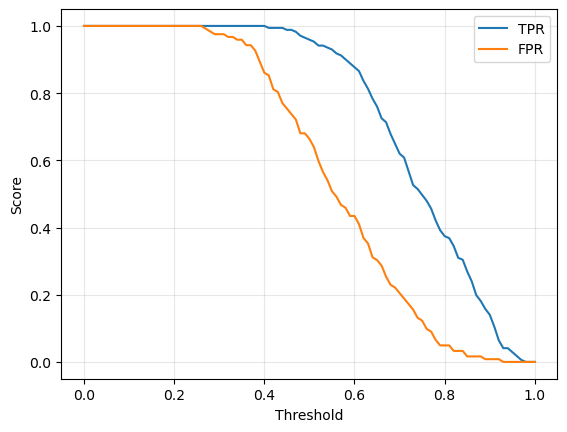

In [41]:
plt.plot(df_scores.threshold,df_scores['tpr'],label='TPR')
plt.plot(df_scores.threshold,df_scores['fpr'],label='FPR')
plt.legend() 
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.show()

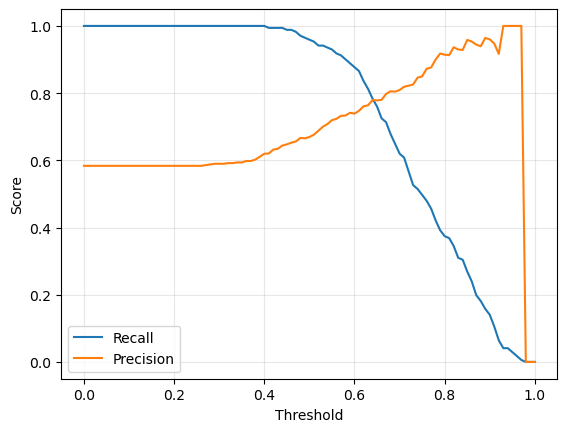

In [44]:
# 绘制 Precision 和 Recall 曲线
plt.plot(df_scores.threshold, df_scores['recall'], label='Recall')
plt.plot(df_scores.threshold, df_scores['precision'], label='Precision')
plt.legend()
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
df_scores

,threshold,tp,fp,fn,tn,tpr,fpr,precision,recall,diff
0,0.00,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.416382
1,0.01,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.416382
2,0.02,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.416382
3,0.03,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.416382
4,0.04,171,122,0,0,1.000000,1.0,0.583618,1.000000,0.416382
...,...,...,...,...,...,...,...,...,...,...
96,0.96,3,0,168,122,0.017544,0.0,1.000000,0.017544,0.982456
97,0.97,1,0,170,122,0.005848,0.0,1.000000,0.005848,0.994152
98,0.98,0,0,171,122,0.000000,0.0,0.000000,0.000000,0.000000
99,0.99,0,0,171,122,0.000000,0.0,0.000000,0.000000,0.000000


### 阈值升高 → 误报率（FPR）↓ + 精确率（Precision）↑ + 召回率（Recall）↓
### 阈值降低 → 误报率（FPR）↑ + 精确率（Precision）↓ + 召回率（Recall）↑

### Question 4: F1 score
 F1分数  
精确率和召回率是相互矛盾的——当一个提高时，另一个就会下降。因此，它们通常被结合成F1分数，这是一种同时考虑两者性能的指标。

计算F1的公式如下：
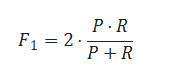

其中 P 是精确率，R 是召回率。  
我们计算从 0.0 到 1.0，以 0.01 为增量的所有阈值下的 F1 值。  
在哪个阈值时 F1 最大？

0.14
0.34
0.54
0.74

In [47]:

# 你已经有了阈值和 df_scores，现在直接基于它计算 F1
df_scores['f1'] = 2 * (df_scores['precision'] * df_scores['recall']) / (df_scores['precision'] + df_scores['recall'])

# 处理分母为 0 的情况（用 0 填充）
df_scores['f1'] = df_scores['f1'].fillna(0)

# 找出最佳阈值
best_idx = df_scores['f1'].idxmax()
best_threshold = df_scores.loc[best_idx, 'threshold']
best_f1 = df_scores.loc[best_idx, 'f1']

print(f"最佳阈值: {best_threshold:.2f}")
print(f"最佳 F1 分数: {best_f1:.4f}")
print(f"对应精确率: {df_scores.loc[best_idx, 'precision']:.4f}")
print(f"对应召回率: {df_scores.loc[best_idx, 'recall']:.4f}")

最佳阈值: 0.57
最佳 F1 分数: 0.8125
对应精确率: 0.7324
对应召回率: 0.9123


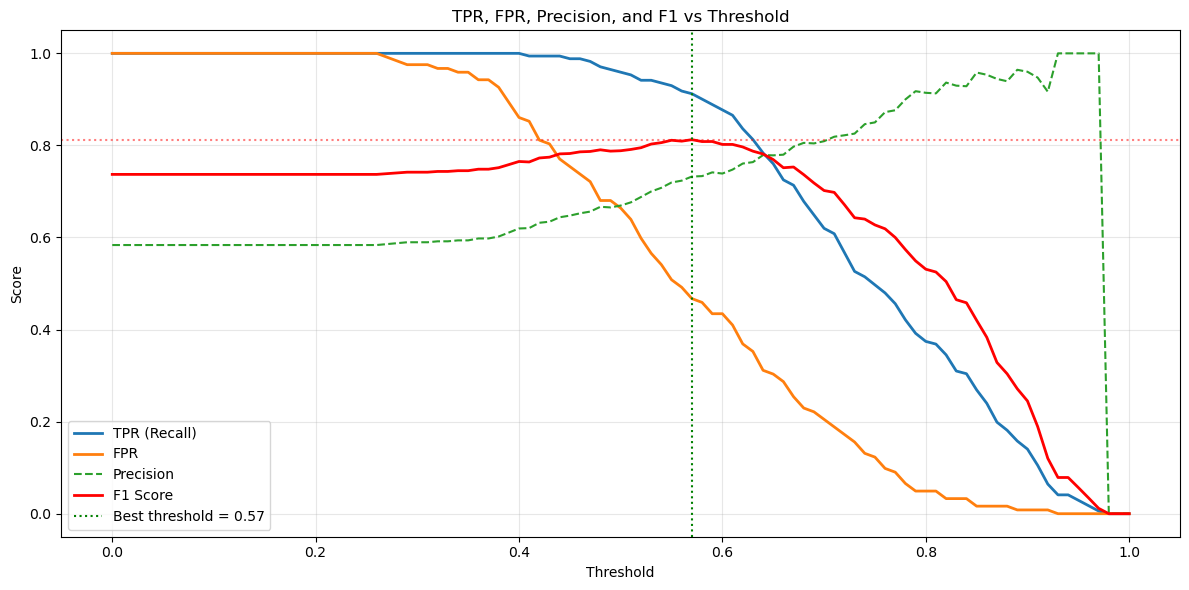

In [48]:
plt.figure(figsize=(12, 6))

# 绘制 TPR、FPR、F1
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR (Recall)', linewidth=2)
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR', linewidth=2)
plt.plot(df_scores.threshold, df_scores['precision'], label='Precision', linestyle='--')
plt.plot(df_scores.threshold, df_scores['f1'], label='F1 Score', linewidth=2, color='red')

# 标记最佳阈值
plt.axvline(x=best_threshold, color='green', linestyle=':', label=f'Best threshold = {best_threshold:.2f}')
plt.axhline(y=best_f1, color='red', linestyle=':', alpha=0.5)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('TPR, FPR, Precision, and F1 vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 问题5：5折交叉验证  
使用Scikit-Learn中的KFold类，在5个不同的数据折上评估我们的模型：

KFold(n_splits=5, shuffle=True, random_state=1)  
遍历df_full_train的不同折  
将数据划分为训练集和验证集  
使用以下参数在训练集上训练模型：LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)  
使用AUC在验证集上评估模型  
不同折之间的得分标准差有多大？

0.00010.006
0.06
0.36

1. 什么是 KFold？
KFold 是交叉验证的一种方法，用来评估模型在不同数据子集上的表现是否稳定。

简单说：把数据分成5份，轮流用其中4份训练，1份验证，重复5次。


In [52]:
df_full_train

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
98,referral,NA,1,56659.0,employed,asia,4,0.75,1
1188,social_media,education,2,66171.0,unemployed,north_america,2,0.66,0
1407,events,finance,1,66523.0,self_employed,europe,3,0.64,1
1083,social_media,finance,1,56746.0,student,north_america,3,0.98,0
404,referral,NA,0,55449.0,student,australia,4,0.47,0
...,...,...,...,...,...,...,...,...,...
715,referral,NA,2,35103.0,unemployed,africa,0,0.88,0
905,social_media,other,1,66006.0,employed,south_america,5,0.64,1
1096,events,finance,2,73688.0,self_employed,asia,2,0.07,0
235,referral,technology,2,76723.0,employed,north_america,3,0.49,1


In [53]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. 提取特征和目标变量
X_full_train = df_full_train[categorical + numerical]
y_full_train = df_full_train['converted'].values

# 2. 转换为字典并向量化
train_dicts_full = X_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full = dv.fit_transform(train_dicts_full)

# 3. 5折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=1)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_full), 1): #kf.split(X_full) 会循环生成5组索引对 (train_idx, val_idx),4个训练，1个验证
    # 分割数据
    X_train_fold = X_full[train_idx]
    X_val_fold = X_full[val_idx]
    y_train_fold = y_full_train[train_idx]
    y_val_fold = y_full_train[val_idx]
    
    # 训练模型
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    
    # 预测并计算 AUC
    y_pred_fold = model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_pred_fold)
    auc_scores.append(auc)
    
    print(f"Fold {fold}: AUC = {auc:.4f}")

# 4. 计算统计量
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)

print(f"\n5折交叉验证 AUC 分数: {[round(x, 4) for x in auc_scores]}")
print(f"平均 AUC: {mean_auc:.4f}")
print(f"标准差: {std_auc:.4f}")
print(f"\n标准差四舍五入到3位小数: {std_auc:.3f}")

Fold 1: AUC = 0.8061
Fold 2: AUC = 0.8714
Fold 3: AUC = 0.7754
Fold 4: AUC = 0.8018
Fold 5: AUC = 0.8558

5折交叉验证 AUC 分数: [0.8061, 0.8714, 0.7754, 0.8018, 0.8558]
平均 AUC: 0.8221
标准差: 0.0358

标准差四舍五入到3位小数: 0.036


### 标准差越小 = 数据波动越小 = 模型越稳定

## Question 6: Hyperparameter Tuning    超参数调优

用5折交叉验证来找到最佳的正则化参数 C

In [54]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. 准备数据（使用 df_full_train）
X_full_train = df_full_train[categorical + numerical]
y_full_train = df_full_train['converted'].values

# 2. 转换为字典并向量化
train_dicts_full = X_full_train.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full = dv.fit_transform(train_dicts_full)

# 3. 定义要测试的 C 值
C_values = [0.000001, 0.001, 1]

# 4. 初始化 KFold（与之前相同）
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# 5. 存储结果
results = []

for C in C_values:
    auc_scores = []
    
    for train_idx, val_idx in kf.split(X_full):
        # 分割数据
        X_train_fold = X_full[train_idx]
        X_val_fold = X_full[val_idx]
        y_train_fold = y_full_train[train_idx]
        y_val_fold = y_full_train[val_idx]
        
        # 训练模型
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train_fold, y_train_fold)
        
        # 预测并计算 AUC
        y_pred_fold = model.predict_proba(X_val_fold)[:, 1]
        auc = roc_auc_score(y_val_fold, y_pred_fold)
        auc_scores.append(auc)
    
    # 计算均值和标准差
    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    
    results.append({
        'C': C,
        'mean': mean_auc,
        'std': std_auc,
        'scores': auc_scores
    })
    
    print(f"C = {C}:")
    print(f"  各折 AUC: {[round(x, 4) for x in auc_scores]}")
    print(f"  平均 AUC: {mean_auc:.3f}")
    print(f"  标准差:   {std_auc:.3f}")
    print()

# 6. 找出最佳 C（先比均值，再比标准差）
# 按均值降序排序，如果均值相同，按标准差升序排序
best_result = min(results, key=lambda x: (-x['mean'], x['std']))

print("=" * 50)
print(f"最佳 C 值: {best_result['C']}")
print(f"对应平均 AUC: {best_result['mean']:.3f}")
print(f"对应标准差: {best_result['std']:.3f}")
print("=" * 50)

C = 1e-06:
  各折 AUC: [0.5572, 0.5192, 0.5895, 0.5582, 0.5769]
  平均 AUC: 0.560
  标准差:   0.024

C = 0.001:
  各折 AUC: [0.8609, 0.8967, 0.8228, 0.854, 0.9]
  平均 AUC: 0.867
  标准差:   0.029

C = 1:
  各折 AUC: [0.8061, 0.8714, 0.7754, 0.8018, 0.8558]
  平均 AUC: 0.822
  标准差:   0.036

最佳 C 值: 0.001
对应平均 AUC: 0.867
对应标准差: 0.029
